# Regresión logística: de los fundamentos a los LLM
**Inteligencia Artificial · UTB** — Edwin Puertas, PhD.

Notebook que acompaña la presentación `AI_Lecture08c_LogisticRegression.pptx`. Reúne:
- **00** Conceptos fundamentales y **S** validación de supuestos.
- **16 tópicos**, cada uno con dos ejemplos ejecutables y una gráfica.

Todos los datos son sintéticos o vienen incluidos en scikit-learn: el notebook se ejecuta **sin internet**.
Requisitos: `numpy`, `scipy`, `pandas`, `scikit-learn ≥ 1.8`, `statsmodels`, `matplotlib`.

In [1]:
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from scipy.special import expit, log_softmax
NAVY, DARK, GREEN, LIME, CYAN, GRAY, RED = "#2C4293", "#1E2A5A", "#098559", "#A0CE3A", "#2CB5E0", "#5D658C", "#C0392B"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 8, "axes.edgecolor": "#C9D0E8",
    "axes.labelcolor": DARK, "xtick.color": GRAY, "ytick.color": GRAY, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#E8EEF6", "grid.linewidth": 0.6,
    "axes.titlesize": 8.5, "axes.titlecolor": DARK, "legend.frameon": False, "legend.fontsize": 7,
    "lines.linewidth": 1.8, "axes.facecolor": "white"})
U = (4.55, 2.36); C = (4.35, 2.55); A = (3.45, 1.91)
def save(fig, name):
    fig.tight_layout(pad=0.4); fig.savefig(OUT + name + ".png", dpi=220); plt.close(fig)
import sklearn
assert tuple(map(int, sklearn.__version__.split('.')[:2])) >= (1, 8), 'Se requiere scikit-learn >= 1.8'
%matplotlib inline
from sklearn.datasets import load_iris, load_breast_cancer, make_classification, load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

## 00 · Conceptos fundamentales
- **y binaria** y probabilidad condicional p(x) = P(y = 1 | x) con y ~ Bernoulli(p).
- **Odds** = p/(1 − p) y **logit** = ln(odds): el modelo es lineal en el logit.
- **Sigmoide** σ(z) = 1/(1 + e⁻ᶻ): inversa del logit.
- **Máxima verosimilitud**: β̂ maximiza ℓ(β) = Σ[yᵢ ln pᵢ + (1 − yᵢ) ln(1 − pᵢ)].
- **Odds ratio** e^βⱼ, pruebas de Wald y de razón de verosimilitud, pseudo-R² de McFadden.

In [2]:
import numpy as np, statsmodels.api as sm

rng = np.random.default_rng(0)
n = 300
estudio = rng.uniform(0, 10, n)                  # horas de estudio
sueno = rng.uniform(4, 9, n)                     # horas de sueño
z = -6 + 0.7 * estudio + 0.5 * sueno             # log-odds verdaderos
aprueba = rng.binomial(1, 1 / (1 + np.exp(-z)))  # y ∈ {0, 1}

X = sm.add_constant(np.column_stack([estudio, sueno]))
res = sm.Logit(aprueba, X).fit(disp=0)           # máxima verosimilitud

for nom, b, se, zv in zip(["intercepto", "estudio", "sueño"],
                          res.params, res.bse, res.tvalues):
    print(f"{nom:10s} b = {b:6.3f}  SE = {se:.3f}  z = {zv:5.1f}  OR = {np.exp(b):6.3f}")
print(f"log-verosimilitud = {res.llf:.1f}   pseudo-R² McFadden = {res.prsquared:.3f}")
print(f"Prueba de razón de verosimilitud: p = {res.llr_pvalue:.1e}")

intercepto b = -5.975  SE = 1.018  z =  -5.9  OR =  0.003
estudio    b =  0.713  SE = 0.080  z =   9.0  OR =  2.041
sueño      b =  0.488  SE = 0.132  z =   3.7  OR =  1.628
log-verosimilitud = -111.2   pseudo-R² McFadden = 0.431
Prueba de razón de verosimilitud: p = 2.7e-37


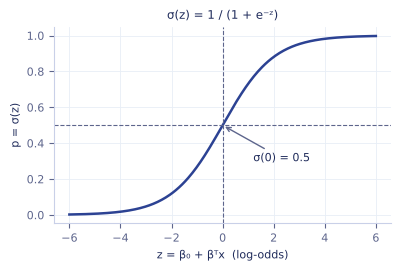

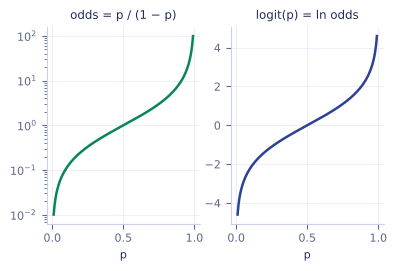

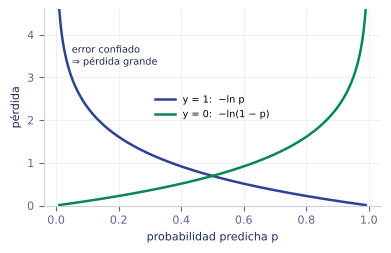

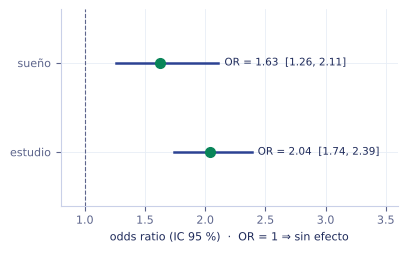

In [3]:
z = np.linspace(-6, 6, 300)
fig, ax = plt.subplots(figsize=C)
ax.plot(z, expit(z), color=NAVY); ax.axhline(0.5, color=GRAY, lw=0.8, ls="--"); ax.axvline(0, color=GRAY, lw=0.8, ls="--")
ax.annotate("σ(0) = 0.5", (0, 0.5), (1.2, 0.3), color=DARK, arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_xlabel("z = β₀ + βᵀx  (log-odds)"); ax.set_ylabel("p = σ(z)"); ax.set_title("σ(z) = 1 / (1 + e⁻ᶻ)")
plt.show()

p = np.linspace(0.01, 0.99, 300)
fig, axs = plt.subplots(1, 2, figsize=C)
axs[0].plot(p, p / (1 - p), color=GREEN); axs[0].set_yscale("log"); axs[0].set_title("odds = p / (1 − p)"); axs[0].set_xlabel("p")
axs[1].plot(p, np.log(p / (1 - p)), color=NAVY); axs[1].set_title("logit(p) = ln odds"); axs[1].set_xlabel("p")
plt.show()

fig, ax = plt.subplots(figsize=C)
ax.plot(p, -np.log(p), color=NAVY, label="y = 1:  −ln p"); ax.plot(p, -np.log(1 - p), color=GREEN, label="y = 0:  −ln(1 − p)")
ax.set_xlabel("probabilidad predicha p"); ax.set_ylabel("pérdida"); ax.legend(); ax.set_ylim(0, 4.6)
ax.text(0.05, 3.3, "error confiado\n⇒ pérdida grande", color=DARK, fontsize=7)
plt.show()

orr = {"estudio": (2.041, 0.713, 0.080), "sueño": (1.628, 0.488, 0.132)}
fig, ax = plt.subplots(figsize=C)
for i, (k, (o, b, se)) in enumerate(orr.items()):
    lo, hi = np.exp(b - 1.96 * se), np.exp(b + 1.96 * se)
    ax.plot([lo, hi], [i, i], color=NAVY); ax.plot(o, i, "o", color=GREEN, ms=7)
    ax.text(hi + 0.05, i, f"OR = {o:.2f}  [{lo:.2f}, {hi:.2f}]", va="center", color=DARK, fontsize=7.5)
ax.axvline(1, color=GRAY, ls="--", lw=0.8); ax.set_yticks([0, 1], list(orr)); ax.set_xlim(0.8, 3.6); ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("odds ratio (IC 95 %)  ·  OR = 1 ⇒ sin efecto"); plt.show()

## S · Supuestos del modelo logístico
1. Respuesta binaria/categórica adecuada · 2. Independencia · 3. Linealidad en el logit · 4. Sin multicolinealidad
5. Sin observaciones influyentes · 6. Tamaño de muestra (EPV ≥ 10) · 7. Sin separación perfecta

No se suponen normalidad ni homocedasticidad.

In [4]:
import numpy as np, statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.stats.stattools import durbin_watson

def validar_supuestos_logit(X, y):
    Xc = sm.add_constant(X)
    glm = sm.GLM(y, Xc, family=sm.families.Binomial()).fit()
    bt = sm.GLM(y, np.column_stack([Xc, X * np.log(X)]),          # Box–Tidwell
                family=sm.families.Binomial()).fit()
    cook = glm.get_influence().cooks_distance[0]
    print("1 Linealidad logit  p(Box–Tidwell):", np.round(bt.pvalues[-X.shape[1]:], 3))
    print("2 Independencia     Durbin–Watson :", round(durbin_watson(glm.resid_pearson), 2))
    print("3 Multicolinealidad VIF           :",
          np.round([vif(Xc, j) for j in range(1, Xc.shape[1])], 2))
    print("4 Influyentes       Cook > 4/n    :", int((cook > 4 / len(y)).sum()), "puntos")
    print("5 Tamaño muestra    EPV           :", min(y.sum(), len(y) - y.sum()) // X.shape[1])
    print("6 Separación        max|β|        :", round(np.abs(glm.params).max(), 2))

rng = np.random.default_rng(1)
X = rng.uniform(1, 10, (400, 2))
y = rng.binomial(1, 1 / (1 + np.exp(-(-4 + 0.6 * X[:, 0] + 0.3 * X[:, 1]))))
validar_supuestos_logit(X, y)

1 Linealidad logit  p(Box–Tidwell): [0.969 0.784]
2 Independencia     Durbin–Watson : 2.01
3 Multicolinealidad VIF           : [1. 1.]
4 Influyentes       Cook > 4/n    : 22 puntos
5 Tamaño muestra    EPV           : 71
6 Separación        max|β|        : 3.34


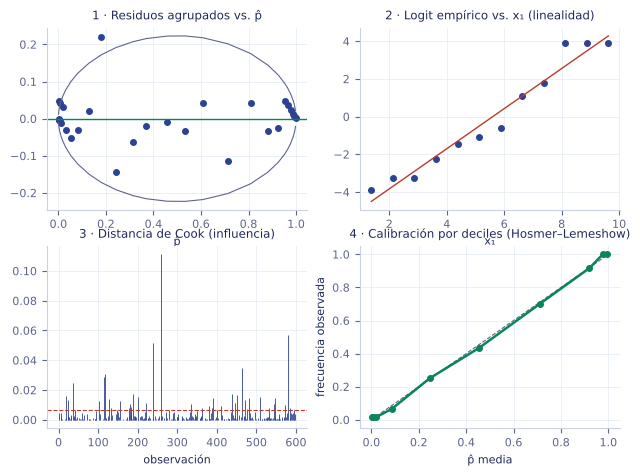

In [5]:
import statsmodels.api as sm
n = 600; x1 = rng.uniform(1, 10, n); x2 = rng.uniform(1, 10, n)
y = rng.binomial(1, expit(-6 + 0.12 * x1 ** 2 + 0.3 * x2))
Xc = sm.add_constant(np.column_stack([x1, x2])); g = sm.GLM(y, Xc, family=sm.families.Binomial()).fit()
ph = g.fittedvalues; r = y - ph
fig, axs = plt.subplots(2, 2, figsize=(7.4, 5.2))
o = np.argsort(ph); k = np.array_split(o, 30)
axs[0, 0].plot([ph[i].mean() for i in k], [r[i].mean() for i in k], "o", color=NAVY, ms=4)
se = [2 * np.sqrt((ph[i] * (1 - ph[i])).mean() / len(i)) for i in k]
axs[0, 0].plot([ph[i].mean() for i in k], se, color=GRAY, lw=0.8); axs[0, 0].plot([ph[i].mean() for i in k], -np.array(se), color=GRAY, lw=0.8)
axs[0, 0].axhline(0, color=GREEN, lw=1); axs[0, 0].set_title("1 · Residuos agrupados vs. p̂"); axs[0, 0].set_xlabel("p̂")
bins = np.linspace(1, 10, 13); c = (bins[:-1] + bins[1:]) / 2
pm = np.array([y[(x1 >= bins[i]) & (x1 < bins[i + 1])].mean() for i in range(12)]).clip(0.02, 0.98)
axs[0, 1].plot(c, np.log(pm / (1 - pm)), "o", color=NAVY, ms=4); axs[0, 1].plot(c, np.poly1d(np.polyfit(c, np.log(pm / (1 - pm)), 1))(c), color=RED, lw=1)
axs[0, 1].set_title("2 · Logit empírico vs. x₁ (linealidad)"); axs[0, 1].set_xlabel("x₁")
cd = g.get_influence().cooks_distance[0]
axs[1, 0].vlines(np.arange(n), 0, cd, color=NAVY, lw=0.6); axs[1, 0].axhline(4 / n, color=RED, ls="--", lw=0.8)
axs[1, 0].set_title("3 · Distancia de Cook (influencia)"); axs[1, 0].set_xlabel("observación")
qb = np.array_split(o, 10)
axs[1, 1].plot([0, 1], [0, 1], color=GRAY, ls="--", lw=0.8)
axs[1, 1].plot([ph[i].mean() for i in qb], [y[i].mean() for i in qb], "o-", color=GREEN, ms=4)
axs[1, 1].set_title("4 · Calibración por deciles (Hosmer–Lemeshow)"); axs[1, 1].set_xlabel("p̂ media"); axs[1, 1].set_ylabel("frecuencia observada")
plt.show()

## 01 · Modelo logístico binario
*Sigmoide, odds y logit: de un puntaje lineal a una probabilidad*

- **Variable respuesta y:** binaria, y ∈ {0, 1} (aprueba/reprueba, spam/no spam, maligno/benigno).
- **Objetivo:** modelar p(x) = P(y = 1 | x), la probabilidad de la clase positiva.
- **Puntaje lineal:** z = β₀ + β₁x₁ + … + β_p x_p = βᵀx; puede tomar cualquier valor real.
- **Función sigmoide:** σ(z) = 1 / (1 + e⁻ᶻ) transforma z en una probabilidad entre 0 y 1.
- **Odds:** p / (1 − p); odds = 3 significa que y = 1 es tres veces más probable que y = 0.
- **Logit:** ln(p / (1 − p)) = βᵀx; el modelo es lineal en los log-odds, no en p.
- **Coeficiente βⱼ:** +1 en xⱼ suma βⱼ al logit y multiplica los odds por e^βⱼ (odds ratio).
- **Decisión:** ŷ = 1 si p ≥ 0.5, equivalente a z ≥ 0; es un clasificador lineal.
- **Familia GLM:** Bernoulli + enlace logit; RN §19.6.5 la presenta como clasificador lineal suave.

> `p = σ(βᵀx) = 1 / (1 + e^(−βᵀx))`
> `ln( p / (1 − p) ) = β₀ + Σ βⱼ xⱼ`

### Ejemplo 1 — Sigmoide, odds y logit (`t01a.py`)
- σ(0) = 0.5: z = 0 es la frontera.
- logit(σ(z)) = z: son funciones inversas.
- Sumar 1 a z multiplica los odds por e ≈ 2.72.

In [6]:
import numpy as np

z = np.array([-4, -2, 0, 1, 2, 4])           # puntaje lineal z = β₀ + βᵀx
p = 1 / (1 + np.exp(-z))                     # sigmoide σ(z) ∈ (0, 1)
odds = p / (1 - p)                           # razón de probabilidades
logit = np.log(odds)                         # recupera z

print("   z    p = σ(z)     odds    logit")
for zi, pi, oi, li in zip(z, p, odds, logit):
    print(f"{zi:4d}    {pi:.3f}    {oi:8.3f}   {li:5.2f}")
print("Sumar 1 a z multiplica los odds por e =", round(np.e, 3))

   z    p = σ(z)     odds    logit
  -4    0.018       0.018   -4.00
  -2    0.119       0.135   -2.00
   0    0.500       1.000    0.00
   1    0.731       2.718    1.00
   2    0.881       7.389    2.00
   4    0.982      54.598    4.00
Sumar 1 a z multiplica los odds por e = 2.718


**Gráfica del ejemplo resuelto**

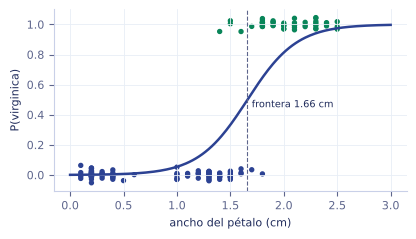

In [7]:
iris = load_iris(); Xw = iris.data[:, [3]]; yv = (iris.target == 2).astype(int)
m = LogisticRegression().fit(Xw, yv); xx = np.linspace(0, 3, 200)
fig, ax = plt.subplots(figsize=U)
ax.scatter(Xw[:, 0], yv + rng.normal(0, 0.02, 150), s=8, color=[GREEN if t else NAVY for t in yv])
ax.plot(xx, m.predict_proba(xx[:, None])[:, 1], color=NAVY); ax.axvline(1.66, color=GRAY, ls="--", lw=0.8)
ax.text(1.7, 0.45, "frontera 1.66 cm", color=DARK, fontsize=7); ax.set_xlabel("ancho del pétalo (cm)"); ax.set_ylabel("P(virginica)")
plt.show()

### Ejemplo 2 — Iris virginica con un predictor (`t01b.py`)
- La frontera es −b₀/b₁ = 1.66 cm.
- predict_proba da p; predict aplica el umbral 0.5.
- Mismo ejemplo del deck 08b (Géron, cap. 4).

In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X = iris.data[:, [3]]                        # ancho del pétalo (cm)
y = (iris.target == 2).astype(int)           # 1 si es Iris virginica

modelo = LogisticRegression().fit(X, y)
b0, b1 = modelo.intercept_[0], modelo.coef_[0, 0]
print(f"logit(p) = {b0:.2f} + {b1:.2f}·ancho")
print(f"frontera (p = 0.5): ancho = {-b0 / b1:.2f} cm")
for w in [1.0, 1.5, 1.7, 2.0]:
    p = modelo.predict_proba([[w]])[0, 1]
    print(f"ancho {w:.1f} cm → P(virginica) = {p:.3f} → clase {modelo.predict([[w]])[0]}")

logit(p) = -7.19 + 4.33·ancho
frontera (p = 0.5): ancho = 1.66 cm
ancho 1.0 cm → P(virginica) = 0.054 → clase 0
ancho 1.5 cm → P(virginica) = 0.333 → clase 0
ancho 1.7 cm → P(virginica) = 0.543 → clase 1
ancho 2.0 cm → P(virginica) = 0.813 → clase 1


## 02 · Log-loss y máxima verosimilitud
*Por qué la regresión logística minimiza la entropía cruzada*

- **Modelo probabilístico:** yᵢ | xᵢ ~ Bernoulli(pᵢ) con pᵢ = σ(βᵀxᵢ).
- **Verosimilitud:** L(β) = Πᵢ pᵢ^yᵢ (1 − pᵢ)^(1 − yᵢ); probabilidad de los datos observados.
- **Log-verosimilitud:** ℓ(β) = Σᵢ [yᵢ ln pᵢ + (1 − yᵢ) ln(1 − pᵢ)]; más estable que el producto.
- **Log-loss:** J(β) = −ℓ(β)/n; también llamada entropía cruzada binaria.
- **Error confiado:** si y = 1 y p → 0, la pérdida −ln p → ∞; castiga la sobreconfianza.
- **Convexidad:** J(β) es convexa: un único mínimo global si no hay separación.
- **Sin forma cerrada:** a diferencia de OLS, ∇J = 0 no se despeja; se optimiza iterativamente.
- **Por qué no MSE:** MSE con sigmoide no es convexo y da gradientes débiles en errores grandes.
- **Deviance:** D = −2ℓ(β); compara modelos anidados (prueba de razón de verosimilitud).

> `J(β) = −(1/n) Σ [yᵢ ln pᵢ + (1 − yᵢ) ln(1 − pᵢ)]`
> `β̂ = argmax_β ℓ(β) = argmin_β J(β)`

### Ejemplo 1 — Log-loss a mano y con sklearn (`t02a.py`)
- Coinciden el cálculo manual y log_loss().
- La pérdida crece sin límite cuando p → 0 y y = 1.
- Por eso conviene recortar p en [ε, 1 − ε].

In [9]:
import numpy as np
from sklearn.metrics import log_loss

y = np.array([1, 1, 0, 0, 1])
p = np.array([0.9, 0.6, 0.2, 0.4, 0.05])     # P(y = 1) predicha

perdida_i = -(y * np.log(p) + (1 - y) * np.log(1 - p))
for yi, pi, li in zip(y, p, perdida_i):
    print(f"y = {yi}  p = {pi:.2f}  pérdida = {li:.3f}")
print(f"log-loss manual  = {perdida_i.mean():.4f}")
print(f"log-loss sklearn = {log_loss(y, p):.4f}")
aporte = perdida_i[-1] / perdida_i.sum() * 100
print(f"Error confiado (y=1, p=0.05) aporta {aporte:.0f} % del total")

y = 1  p = 0.90  pérdida = 0.105
y = 1  p = 0.60  pérdida = 0.511
y = 0  p = 0.20  pérdida = 0.223
y = 0  p = 0.40  pérdida = 0.511
y = 1  p = 0.05  pérdida = 2.996
log-loss manual  = 0.8692
log-loss sklearn = 0.8692
Error confiado (y=1, p=0.05) aporta 69 % del total


**Gráfica del ejemplo resuelto**

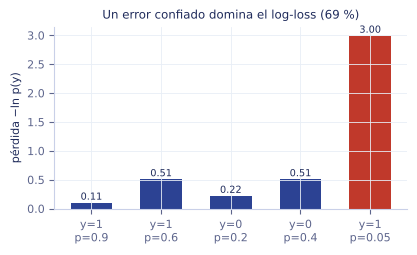

In [10]:
yy = np.array([1, 1, 0, 0, 1]); pp = np.array([0.9, 0.6, 0.2, 0.4, 0.05]); L = -(yy * np.log(pp) + (1 - yy) * np.log(1 - pp))
fig, ax = plt.subplots(figsize=U)
ax.bar([f"y={a}\np={b}" for a, b in zip(yy, pp)], L, color=[NAVY] * 4 + [RED], width=0.6)
for i, v in enumerate(L): ax.text(i, v + 0.05, f"{v:.2f}", ha="center", color=DARK, fontsize=7)
ax.set_ylabel("pérdida −ln p(y)"); ax.set_title("Un error confiado domina el log-loss (69 %)"); plt.show()

### Ejemplo 2 — Máxima verosimilitud con scipy (`t02b.py`)
- scipy y sklearn (C = ∞) dan el mismo β̂.
- β̂ se acerca al β real con n = 3000.
- np.logaddexp evita desbordes en ln(1 + eᶻ).

In [11]:
import numpy as np
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(2)
X = rng.normal(0, 1, (3000, 2))
y = rng.binomial(1, 1 / (1 + np.exp(-(0.5 + 2 * X[:, 0] - 1 * X[:, 1]))))
Xb = np.column_stack([np.ones(len(X)), X])

def nll(beta):                               # −log-verosimilitud estable
    z = Xb @ beta
    return np.sum(np.logaddexp(0, z) - y * z)

mle = minimize(nll, np.zeros(3), method="BFGS").x
sk = LogisticRegression(C=np.inf).fit(X, y)  # sin regularización
print("MLE scipy  :", np.round(mle, 3))
print("sklearn    :", np.round(np.r_[sk.intercept_, sk.coef_[0]], 3))
print("Verdadero  : [ 0.5  2.  -1. ]   −logL =", round(nll(mle), 2))

MLE scipy  : [ 0.532  1.958 -0.979]
sklearn    : [ 0.533  1.959 -0.979]
Verdadero  : [ 0.5  2.  -1. ]   −logL = 1296.9


## 03 · Optimización
*Descenso de gradiente, SGD, Newton–Raphson/IRLS y L-BFGS*

- **Gradiente:** ∇J(β) = (1/n) Xᵀ(σ(Xβ) − y); igual forma que en regresión lineal.
- **Descenso de gradiente:** β ← β − η∇J(β); η es la tasa de aprendizaje.
- **SGD / mini-batch:** gradiente con una muestra o un lote; escala a millones de filas.
- **Hessiana:** H = Xᵀ W X con W = diag(pᵢ(1 − pᵢ)); es definida positiva ⇒ J convexa.
- **Newton–Raphson:** β ← β + H⁻¹ Xᵀ(y − p); convergencia cuadrática en pocas iteraciones.
- **IRLS:** Newton reescrito como mínimos cuadrados ponderados repetidos (statsmodels, R glm).
- **L-BFGS:** cuasi-Newton con memoria limitada; solver por defecto de scikit-learn.
- **SAGA / liblinear:** solvers para L1, Elastic Net y datos dispersos de alta dimensión.
- **Subproducto:** H⁻¹ en el óptimo estima Var(β̂) ⇒ errores estándar e intervalos.

> `GD:  β ← β − η · Xᵀ(σ(Xβ) − y) / n`
> `Newton:  β ← β + (XᵀWX)⁻¹ Xᵀ(y − p)`

### Ejemplo 1 — Descenso de gradiente desde cero (`t03a.py`)
- El gradiente tiene la forma Xᵀ(p − y).
- ‖∇‖ → 0 al converger.
- Coincide con LogisticRegression(C = ∞).

In [12]:
import numpy as np
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(3)
n = 1000
X = np.column_stack([np.ones(n), rng.normal(0, 1, (n, 2))])
y = rng.binomial(1, 1 / (1 + np.exp(-(X @ np.array([-0.5, 1.5, -2.0])))))

beta, eta = np.zeros(3), 0.5
for epoca in range(1, 2001):
    p = 1 / (1 + np.exp(-X @ beta))
    grad = X.T @ (p - y) / n                 # ∇J = Xᵀ(σ(Xβ) − y)/n
    beta -= eta * grad
    if epoca in (1, 10, 100, 2000):
        print(f"época {epoca:4d}  β = {np.round(beta, 3)}  ‖∇‖ = {np.linalg.norm(grad):.1e}")
sk = LogisticRegression(C=np.inf).fit(X[:, 1:], y)
print("sklearn      β =", np.round(np.r_[sk.intercept_, sk.coef_[0]], 3))

época    1  β = [-0.031  0.091 -0.125]  ‖∇‖ = 3.2e-01
época   10  β = [-0.202  0.589 -0.788]  ‖∇‖ = 1.3e-01
época  100  β = [-0.496  1.384 -1.778]  ‖∇‖ = 5.7e-03


época 2000  β = [-0.525  1.458 -1.869]  ‖∇‖ = 3.2e-16
sklearn      β = [-0.525  1.458 -1.869]


**Gráfica del ejemplo resuelto**

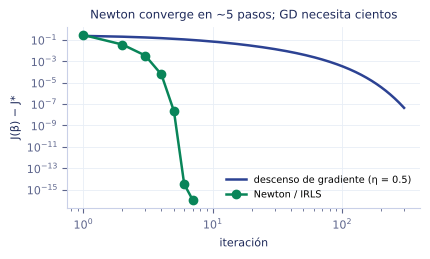

In [13]:
n = 1000; X = np.column_stack([np.ones(n), np.random.default_rng(3).normal(0, 1, (n, 2))])
r3 = np.random.default_rng(3); r3.normal(0, 1, (n, 2)); Xg = X
yb = np.random.default_rng(3); 
rngx = np.random.default_rng(3); Xg = np.column_stack([np.ones(n), rngx.normal(0, 1, (n, 2))]); yg = rngx.binomial(1, expit(Xg @ np.array([-0.5, 1.5, -2.0])))
nl = lambda b: np.sum(np.logaddexp(0, Xg @ b) - yg * (Xg @ b)) / n
b = np.zeros(3); gd = []
for e in range(300):
    b -= 0.5 * Xg.T @ (expit(Xg @ b) - yg) / n; gd.append(nl(b))
b = np.zeros(3); nw = [nl(b)]
for e in range(6):
    pq = expit(Xg @ b); H = Xg.T @ ((pq * (1 - pq))[:, None] * Xg); b = b + np.linalg.solve(H, Xg.T @ (yg - pq)); nw.append(nl(b))
opt = min(nw)
fig, ax = plt.subplots(figsize=U)
ax.semilogy(np.arange(1, 301), np.array(gd) - opt + 1e-16, color=NAVY, label="descenso de gradiente (η = 0.5)")
ax.semilogy(np.arange(1, 8), np.array(nw) - opt + 1e-16, "o-", color=GREEN, label="Newton / IRLS")
ax.set_xlabel("iteración"); ax.set_ylabel("J(β) − J*"); ax.legend(); ax.set_xscale("log"); ax.set_title("Newton converge en ~5 pasos; GD necesita cientos"); plt.show()

### Ejemplo 2 — Newton–Raphson / IRLS (`t03b.py`)
- −logL deja de cambiar en la 5.ª iteración.
- W = p(1 − p) pondera cada observación.
- √diag(H⁻¹) da los errores estándar.

In [14]:
import numpy as np

rng = np.random.default_rng(3)
n = 1000
X = np.column_stack([np.ones(n), rng.normal(0, 1, (n, 2))])
y = rng.binomial(1, 1 / (1 + np.exp(-(X @ np.array([-0.5, 1.5, -2.0])))))

beta = np.zeros(3)                           # Newton–Raphson = IRLS
for it in range(1, 7):
    p = 1 / (1 + np.exp(-X @ beta))
    W = p * (1 - p)                          # pesos de la Hessiana
    H = X.T @ (W[:, None] * X)               # H = Xᵀ W X
    beta = beta + np.linalg.solve(H, X.T @ (y - p))
    nll = np.sum(np.logaddexp(0, X @ beta) - y * (X @ beta))
    print(f"iter {it}  β = {np.round(beta, 4)}  −logL = {nll:.4f}")
print("SE(β) =", np.round(np.sqrt(np.diag(np.linalg.inv(H))), 3))

iter 1  β = [-0.275   0.8001 -1.0365]  −logL = 452.6348
iter 2  β = [-0.4367  1.2326 -1.5844]  −logL = 420.5182
iter 3  β = [-0.5125  1.4276 -1.8303]  −logL = 417.2102
iter 4  β = [-0.5244  1.4576 -1.8681]  −logL = 417.1535
iter 5  β = [-0.5246  1.4582 -1.8689]  −logL = 417.1535
iter 6  β = [-0.5246  1.4582 -1.8689]  −logL = 417.1535
SE(β) = [0.09  0.115 0.127]


## 04 · Frontera de decisión y umbral
*Del predict_proba al predict: geometría y costos*

- **Frontera de decisión:** conjunto de x con p = 0.5, es decir, βᵀx = 0.
- **Geometría:** un hiperplano en el espacio de x; en 2-D, una recta.
- **Rectas de nivel:** p = c ⇔ βᵀx = logit(c); son paralelas a la frontera.
- **Distancia y confianza:** |βᵀx| / ‖β‖ crece al alejarse de la frontera; p tiende a 0 o 1.
- **predict_proba vs. predict:** el primero entrega p; el segundo aplica el umbral t = 0.5.
- **Umbral t:** parámetro de decisión, no del modelo; se elige según el problema.
- **Umbral de Bayes:** con costos C_FP y C_FN, t* = C_FP / (C_FP + C_FN).
- **Fronteras no lineales:** con φ(x) (polinomios, interacciones) la frontera se curva en x.
- **decision_function:** devuelve z = βᵀx; útil para curvas ROC y calibración.

> `Frontera:  β₀ + β₁x₁ + β₂x₂ = 0`
> `t* = C_FP / (C_FP + C_FN)`

### Ejemplo 1 — Frontera y rectas de igual probabilidad (`t04a.py`)
- Las rectas p = 0.1, 0.5, 0.9 tienen la misma pendiente.
- decision_function devuelve z = βᵀx.
- z > 0 ⇔ p > 0.5.

In [15]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X = iris.data[:, 2:4]                        # largo y ancho del pétalo
y = (iris.target == 2).astype(int)           # virginica vs. resto
m = LogisticRegression(C=np.inf, max_iter=5000).fit(X, y)
b0, (b1, b2) = m.intercept_[0], m.coef_[0]

for p in [0.1, 0.5, 0.9]:                    # rectas de igual probabilidad
    z = np.log(p / (1 - p))                  # logit(p)
    print(f"p = {p:.1f}: ancho = {(z - b0) / b2:6.2f} {-b1 / b2:+.2f}·largo")
nuevo = np.array([[5.0, 1.6]])
print("flor (5.0, 1.6): z =", round(m.decision_function(nuevo)[0], 2),
      " p =", round(m.predict_proba(nuevo)[0, 1], 3))

p = 0.1: ancho =   4.13 -0.55·largo
p = 0.5: ancho =   4.34 -0.55·largo
p = 0.9: ancho =   4.55 -0.55·largo
flor (5.0, 1.6): z = 0.22  p = 0.554


**Gráfica del ejemplo resuelto**

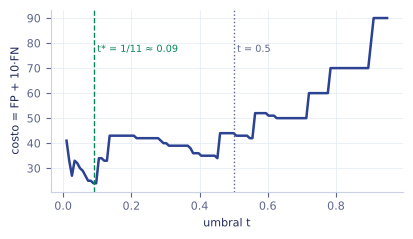

In [16]:
Xb, yb = load_breast_cancer(return_X_y=True); yb = 1 - yb
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, stratify=yb, random_state=0)
pb = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
ts = np.linspace(0.01, 0.95, 120); cost = [((pb >= t) & (yte == 0)).sum() + 10 * ((pb < t) & (yte == 1)).sum() for t in ts]
fig, ax = plt.subplots(figsize=U)
ax.plot(ts, cost, color=NAVY); ax.axvline(1 / 11, color=GREEN, ls="--", lw=1); ax.axvline(0.5, color=GRAY, ls=":", lw=1)
ax.text(0.1, max(cost) * 0.85, "t* = 1/11 ≈ 0.09", color=GREEN, fontsize=7); ax.text(0.51, max(cost) * 0.85, "t = 0.5", color=GRAY, fontsize=7)
ax.set_xlabel("umbral t"); ax.set_ylabel("costo = FP + 10·FN"); plt.show()

### Ejemplo 2 — Umbral de Bayes con costos (`t04b.py`)
- t = 0.5 no minimiza el costo.
- t* = C_FP / (C_FP + C_FN) = 0.091.
- Se gana recall a cambio de precisión.

In [17]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

X, y = load_breast_cancer(return_X_y=True)
y = 1 - y                                    # 1 = maligno (clase positiva)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
modelo = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xtr, ytr)
p = modelo.predict_proba(Xte)[:, 1]

c_fp, c_fn = 1, 10                           # un falso negativo cuesta 10 veces más
t_opt = c_fp / (c_fp + c_fn)                 # umbral de Bayes: t* = C_FP / (C_FP + C_FN)
for t in [0.5, 0.3, round(t_opt, 3)]:
    yh = (p >= t).astype(int)
    fn, fp = ((yh == 0) & (yte == 1)).sum(), ((yh == 1) & (yte == 0)).sum()
    pr, rc = precision_score(yte, yh), recall_score(yte, yh)
    print(f"t = {t:<5}  precisión = {pr:.3f}  recall = {rc:.3f}"
          f"  FN = {fn}  FP = {fp}  costo = {c_fp * fp + c_fn * fn}")

t = 0.5    precisión = 0.938  recall = 0.938  FN = 4  FP = 4  costo = 44
t = 0.3    precisión = 0.859  recall = 0.953  FN = 3  FP = 10  costo = 40
t = 0.091  precisión = 0.818  recall = 0.984  FN = 1  FP = 14  costo = 24


## 05 · Métricas de clasificación
*Matriz de confusión, precisión, recall, F1, ROC-AUC, PR-AUC y Brier*

- **Matriz de confusión:** cuenta TP, FP, TN y FN para un umbral dado.
- **Exactitud:** (TP + TN) / n; engañosa si las clases están desbalanceadas.
- **Precisión:** TP / (TP + FP); de los que marco positivos, cuántos lo son.
- **Recall (sensibilidad, TPR):** TP / (TP + FN); de los positivos, cuántos detecto.
- **F1:** media armónica de precisión y recall; resume ambos en un número.
- **ROC-AUC:** probabilidad de que un positivo tenga mayor p̂ que un negativo; no depende de t.
- **PR-AUC (average precision):** área bajo precisión–recall; preferible con pocos positivos.
- **Log-loss y Brier:** evalúan la calidad de las probabilidades, no solo la clase.
- **Validación cruzada estratificada:** conserva la proporción de clases en cada pliegue.

> `F1 = 2 · Precisión · Recall / (Precisión + Recall)`
> `Brier = (1/n) Σ (p̂ᵢ − yᵢ)²`

### Ejemplo 1 — Matriz de confusión y reporte (`t05a.py`)
- confusion_matrix se lee [[TN, FP], [FN, TP]].
- Precisión y recall de la clase 'maligno'.
- La exactitud (0.953) esconde los 4 FN.

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X, y = load_breast_cancer(return_X_y=True)
y = 1 - y                                    # 1 = maligno
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
modelo = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xtr, ytr)
yh = modelo.predict(Xte)

(tn, fp), (fn, tp) = confusion_matrix(yte, yh)
print(f"TN = {tn}  FP = {fp}  FN = {fn}  TP = {tp}")
print(classification_report(yte, yh, target_names=["benigno", "maligno"], digits=3))

TN = 103  FP = 4  FN = 4  TP = 60
              precision    recall  f1-score   support

     benigno      0.963     0.963     0.963       107
     maligno      0.938     0.938     0.938        64

    accuracy                          0.953       171
   macro avg      0.950     0.950     0.950       171
weighted avg      0.953     0.953     0.953       171



**Gráfica del ejemplo resuelto**

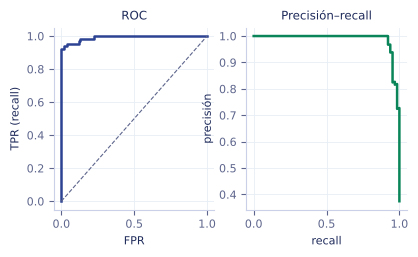

In [19]:
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, _ = roc_curve(yte, pb); pr, rc, _ = precision_recall_curve(yte, pb)
fig, axs = plt.subplots(1, 2, figsize=U)
axs[0].plot(fpr, tpr, color=NAVY); axs[0].plot([0, 1], [0, 1], color=GRAY, ls="--", lw=0.8); axs[0].set_title("ROC"); axs[0].set_xlabel("FPR"); axs[0].set_ylabel("TPR (recall)")
axs[1].plot(rc, pr, color=GREEN); axs[1].set_title("Precisión–recall"); axs[1].set_xlabel("recall"); axs[1].set_ylabel("precisión")
plt.show()

### Ejemplo 2 — Métricas con validación cruzada (`t05b.py`)
- Varias métricas en una sola cross_validate.
- neg_log_loss y neg_brier se cambian de signo.
- La DE entre pliegues mide la estabilidad.

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X, y = load_breast_cancer(return_X_y=True)
y = 1 - y
modelo = make_pipeline(StandardScaler(), LogisticRegression())
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
metricas = {"ROC-AUC": "roc_auc", "PR-AUC": "average_precision",
            "F1": "f1", "Log-loss": "neg_log_loss", "Brier": "neg_brier_score"}
res = cross_validate(modelo, X, y, cv=cv, scoring=metricas)

for nombre in metricas:
    v = res[f"test_{nombre}"]
    v = -v if nombre in ("Log-loss", "Brier") else v
    print(f"{nombre:9s} = {v.mean():.3f} ± {v.std():.3f}")

ROC-AUC   = 0.995 ± 0.006
PR-AUC    = 0.994 ± 0.006
F1        = 0.971 ± 0.020
Log-loss  = 0.074 ± 0.034
Brier     = 0.019 ± 0.008


## 06 · Softmax, one-vs-rest y ordinal
*Regresión logística para más de dos clases*

- **Softmax (multinomial):** un puntaje s_k(x) = β_kᵀx por clase y P(k | x) = e^s_k / Σⱼ e^sⱼ.
- **Normalización:** las K probabilidades suman 1; con K = 2 se reduce a la sigmoide.
- **Pérdida:** entropía cruzada categórica J = −(1/n) Σᵢ ln P(yᵢ | xᵢ).
- **Identificabilidad:** sumar el mismo vector a todos los β_k no cambia las probabilidades.
- **One-vs-rest (OvR):** K clasificadores binarios independientes; probabilidades no coherentes.
- **Frontera multiclase:** regiones convexas separadas por hiperplanos s_k = sⱼ.
- **Logística ordinal:** para clases ordenadas: P(y ≤ k) = σ(θ_k − βᵀx) con umbrales θ₁ < θ₂ < …
- **Odds proporcionales:** el mismo β para todos los cortes; un solo efecto por variable.
- **Puente con los LLM:** la capa de salida de un LLM es una softmax sobre el vocabulario (tópico 14).

> `P(y = k | x) = exp(β_kᵀx) / Σⱼ exp(βⱼᵀx)`
> `Ordinal:  P(y ≤ k | x) = σ(θ_k − βᵀx)`

### Ejemplo 1 — Softmax manual vs. sklearn y OvR (`t06a.py`)
- La softmax manual coincide con predict_proba.
- Softmax: mejor log-loss (0.120) que OvR (0.272).
- Restar el máximo evita desbordes en exp.

In [21]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import log_loss

X, y = load_iris(return_X_y=True)
soft = LogisticRegression(max_iter=1000).fit(X, y)       # multinomial (softmax)
S = X @ soft.coef_.T + soft.intercept_                   # puntajes s_k(x)
P = np.exp(S - S.max(1, keepdims=True))
P /= P.sum(1, keepdims=True)                             # softmax manual
print("softmax manual = sklearn:", np.allclose(P, soft.predict_proba(X)))
print("flor 0  P(k|x) =", np.round(P[0], 3), " flor 100 =", np.round(P[100], 3))

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000)).fit(X, y)
for nom, m in [("Softmax", soft), ("One-vs-Rest", ovr)]:
    ll = log_loss(y, m.predict_proba(X))
    print(f"{nom:12s} exactitud = {m.score(X, y):.3f}  log-loss = {ll:.3f}")

softmax manual = sklearn: True
flor 0  P(k|x) = [0.982 0.018 0.   ]  flor 100 = [0.    0.004 0.996]
Softmax      exactitud = 0.973  log-loss = 0.120
One-vs-Rest  exactitud = 0.953  log-loss = 0.272


### Ejemplo 2 — Regresión logística ordinal (`t06b.py`)
- Un β por variable y K − 1 umbrales.
- Se recuperan los umbrales reales 0 y 2.
- Signo negativo: más espera, menos satisfacción.

In [22]:
import numpy as np, pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

rng = np.random.default_rng(6)
n = 600
espera = rng.uniform(0, 60, n)               # minutos de espera
amabilidad = rng.uniform(1, 5, n)            # calificación del personal
latente = -0.06 * espera + 0.9 * amabilidad + rng.logistic(0, 1, n)
nivel = pd.Series(pd.cut(latente, [-np.inf, 0, 2, np.inf],
                  labels=["bajo", "medio", "alto"]))   # satisfacción ordinal

X = pd.DataFrame({"espera": espera, "amabilidad": amabilidad})
res = OrderedModel(nivel, X, distr="logit").fit(method="bfgs", disp=False)
print("β:", res.params[["espera", "amabilidad"]].round(3).to_dict())
print("umbrales θ:", res.model.transform_threshold_params(res.params)[1:-1].round(3))
nuevo = np.array([[10, 4], [50, 2]])         # (espera, amabilidad)
for x, p in zip(nuevo, res.predict(nuevo)):
    print(f"espera {x[0]:2d} min, amabilidad {x[1]} → P(bajo, medio, alto) = {np.round(p, 3)}")

β: {'espera': -0.058, 'amabilidad': 0.984}
umbrales θ: [0.12  2.262]
espera 10 min, amabilidad 4 → P(bajo, medio, alto) = [0.038 0.213 0.749]
espera 50 min, amabilidad 2 → P(bajo, medio, alto) = [0.743 0.218 0.039]


**Gráfica del ejemplo resuelto**

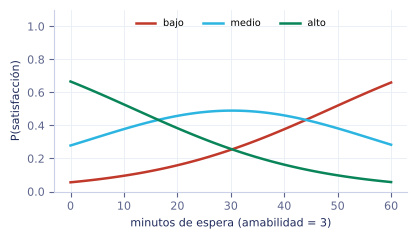

In [23]:
ee = np.linspace(0, 60, 100); P = res.predict(np.column_stack([ee, np.full(100, 3.0)]))
fig, ax = plt.subplots(figsize=U)
for k, (nom, col) in enumerate([("bajo", RED), ("medio", CYAN), ("alto", GREEN)]):
    ax.plot(ee, P[:, k], color=col, label=nom)
ax.set_xlabel("minutos de espera (amabilidad = 3)"); ax.set_ylabel("P(satisfacción)"); ax.legend(ncol=3, loc="upper center"); ax.set_ylim(0, 1.1); plt.show()

## 07 · Regularización
*Ridge (L2), Lasso (L1), Elastic Net y alta dimensión*

- **Problema:** con p grande, colinealidad o separación, el MLE tiene varianza alta o diverge.
- **Objetivo penalizado:** J(β) + λ R(β); en sklearn C = 1/λ (C pequeño = más penalización).
- **Ridge (L2):** R = ‖β‖²₂; encoge todos los coeficientes y estabiliza la Hessiana.
- **Lasso (L1):** R = ‖β‖₁; lleva coeficientes exactamente a 0 ⇒ selección de variables.
- **Elastic Net:** mezcla α‖β‖₁ + (1 − α)‖β‖²₂; útil con grupos de variables correlacionadas.
- **Interpretación bayesiana:** L2 = prior gaussiano; L1 = prior de Laplace (MAP).
- **Escalado obligatorio:** la penalización depende de las unidades: estandarizar X.
- **API actual:** scikit-learn ≥ 1.8 usa l1_ratio (0 = L2, 1 = L1) en lugar de penalty.
- **Alta dimensión (p ≫ n):** genómica, texto: L1 recupera las variables informativas si son pocas.

> `min_β  J(β) + λ [ α‖β‖₁ + (1 − α)‖β‖²₂ / 2 ]`
> `C = 1 / λ   ·   l1_ratio = α`

### Ejemplo 1 — MLE vs. Ridge, Lasso y Elastic Net (`t07a.py`)
- Sin penalización: ‖β‖ enorme (casi separación).
- Lasso deja 8 de 30 coeficientes ≠ 0.
- Las tres penalizaciones superan al MLE en AUC.

In [24]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X, y = load_breast_cancer(return_X_y=True)   # 30 predictores correlacionados
# scikit-learn ≥ 1.8: l1_ratio define la penalización (0 = L2, 1 = L1)
modelos = {
    "Sin penalización": LogisticRegression(C=np.inf, max_iter=20000),
    "Ridge (L2)":       LogisticRegression(C=0.1, l1_ratio=0.0, max_iter=5000),
    "Lasso (L1)":       LogisticRegression(C=0.1, l1_ratio=1.0, solver="saga", max_iter=20000),
    "Elastic Net":      LogisticRegression(C=0.1, l1_ratio=0.5, solver="saga", max_iter=20000)}
for nombre, lr in modelos.items():
    pipe = make_pipeline(StandardScaler(), lr)
    auc = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()
    coef = pipe.fit(X, y)[-1].coef_[0]
    nz = np.sum(np.abs(coef) > 1e-6)
    print(f"{nombre:17s} AUC = {auc:.4f}  ‖β‖₂ = {np.linalg.norm(coef):7.2f}  β≠0: {nz:2d}/30")

Sin penalización  AUC = 0.9862  ‖β‖₂ = 14826.55  β≠0: 30/30
Ridge (L2)        AUC = 0.9951  ‖β‖₂ =    1.95  β≠0: 30/30


Lasso (L1)        AUC = 0.9924  ‖β‖₂ =    2.68  β≠0:  8/30


Elastic Net       AUC = 0.9939  ‖β‖₂ =    1.71  β≠0: 18/30


**Gráfica del ejemplo resuelto**

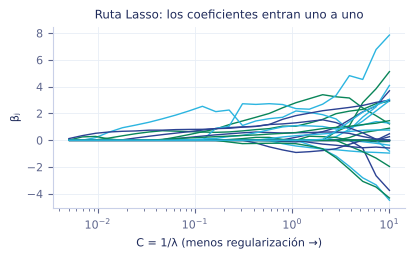

In [25]:
Xs = StandardScaler().fit_transform(Xb); Cs = np.logspace(-2.3, 1, 25); path = []
for Cv in Cs: path.append(LogisticRegression(C=Cv, l1_ratio=1.0, solver="liblinear").fit(Xs, yb).coef_[0])
path = np.array(path); fig, ax = plt.subplots(figsize=U)
for j in range(30): ax.plot(Cs, path[:, j], color=[NAVY, GREEN, CYAN][j % 3], lw=1)
ax.set_xscale("log"); ax.set_xlabel("C = 1/λ (menos regularización →)"); ax.set_ylabel("βⱼ"); ax.set_title("Ruta Lasso: los coeficientes entran uno a uno"); plt.show()

### Ejemplo 2 — Lasso en alta dimensión (p ≫ n) (`t07b.py`)
- p = 1000, n = 200, 10 variables informativas.
- C = 0.05: 6 seleccionadas, todas verdaderas.
- Ridge usa todas y generaliza peor (0.795).

In [26]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Alta dimensión: p = 1000 predictores, n = 200, solo 10 informativos
X, y = make_classification(n_samples=200, n_features=1000, n_informative=10,
                           n_redundant=0, shuffle=False, random_state=7)
for C in [0.01, 0.05, 0.2, 1.0]:
    l1 = LogisticRegression(C=C, l1_ratio=1.0, solver="liblinear")
    acc = cross_val_score(l1, X, y, cv=5).mean()
    sel = np.flatnonzero(l1.fit(X, y).coef_[0])
    print(f"C = {C:<5} exactitud CV = {acc:.3f}  seleccionadas = {len(sel):3d}"
          f"  verdaderas recuperadas = {np.sum(sel < 10)}/10")
l2 = LogisticRegression(C=1.0, max_iter=5000)
acc = cross_val_score(l2, X, y, cv=5).mean()
print(f"Ridge C = 1    exactitud CV = {acc:.3f}  usa las 1000")

C = 0.01  exactitud CV = 0.500  seleccionadas =   1  verdaderas recuperadas = 1/10
C = 0.05  exactitud CV = 0.860  seleccionadas =   6  verdaderas recuperadas = 6/10
C = 0.2   exactitud CV = 0.850  seleccionadas =  39  verdaderas recuperadas = 8/10
C = 1.0   exactitud CV = 0.845  seleccionadas =  79  verdaderas recuperadas = 9/10
Ridge C = 1    exactitud CV = 0.795  usa las 1000


## 08 · Clases desbalanceadas
*Pesos de clase, umbral óptimo y remuestreo*

- **Desbalance:** una clase es rara (fraude 0.1 %, enfermedad 3 %); la exactitud engaña.
- **Efecto en la LR:** el intercepto refleja la prevalencia; p̂ suele quedar por debajo de 0.5.
- **class_weight='balanced':** pondera cada clase por n / (K·n_k) en la log-loss.
- **Ajuste de umbral:** mantener el modelo y mover t; suele bastar y conserva la calibración.
- **Sobremuestreo:** replicar (o sintetizar con SMOTE) la clase minoritaria en train.
- **Submuestreo:** descartar mayoritarios; rápido, pero pierde información.
- **Costo de reponderar:** las probabilidades quedan infladas: recalibrar si se usan como riesgo.
- **Métricas adecuadas:** PR-AUC, recall, balanced accuracy, F1, costo esperado.
- **Regla:** remuestrear solo el conjunto de entrenamiento, nunca validación ni test.

> `w_k = n / (K · n_k)`
> `J_w(β) = −Σ w_yᵢ [yᵢ ln pᵢ + (1 − yᵢ) ln(1 − pᵢ)]`

### Ejemplo 1 — class_weight='balanced' (`t08a.py`)
- Sube el recall, pero cae mucho la precisión.
- La PR-AUC casi no cambia: el ranking es el mismo.
- Elegir según el costo de cada error.

In [27]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score,
                             balanced_accuracy_score, average_precision_score)

X, y = make_classification(n_samples=6000, n_features=10, n_informative=4,
                           weights=[0.97], flip_y=0.01, random_state=8)   # 3 % positivos
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print(f"positivos en test: {yte.sum()} de {len(yte)}")
for nombre, cw in [("Sin ajuste", None), ("class_weight='balanced'", "balanced")]:
    m = LogisticRegression(class_weight=cw, max_iter=1000).fit(Xtr, ytr)
    yh, p = m.predict(Xte), m.predict_proba(Xte)[:, 1]
    r = [recall_score(yte, yh), precision_score(yte, yh),
         balanced_accuracy_score(yte, yh), average_precision_score(yte, p)]
    print(f"{nombre:24s}recall={r[0]:.3f} prec={r[1]:.3f} bal-acc={r[2]:.3f} PR-AUC={r[3]:.3f}")

positivos en test: 60 de 1800
Sin ajuste              recall=0.700 prec=0.977 bal-acc=0.850 PR-AUC=0.814
class_weight='balanced' recall=0.817 prec=0.405 bal-acc=0.888 PR-AUC=0.810


**Gráfica del ejemplo resuelto**

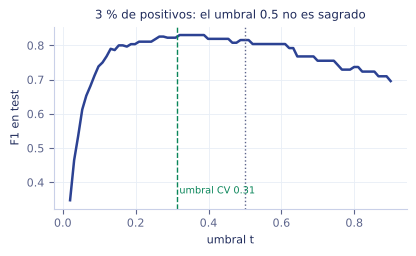

In [28]:
X8, y8 = make_classification(n_samples=6000, n_features=10, n_informative=4, weights=[0.97], flip_y=0.01, random_state=8)
a, b8, c8, d8 = train_test_split(X8, y8, test_size=0.3, stratify=y8, random_state=0)
p8 = LogisticRegression(max_iter=1000).fit(a, c8).predict_proba(b8)[:, 1]
from sklearn.metrics import f1_score
ts = np.linspace(0.02, 0.9, 80); f1 = [f1_score(d8, p8 >= t) for t in ts]
fig, ax = plt.subplots(figsize=U)
ax.plot(ts, f1, color=NAVY); ax.axvline(0.5, color=GRAY, ls=":", lw=1); ax.axvline(0.313, color=GREEN, ls="--", lw=1)
ax.text(0.32, min(f1) + 0.02, "umbral CV 0.31", color=GREEN, fontsize=7); ax.set_xlabel("umbral t"); ax.set_ylabel("F1 en test"); ax.set_title("3 % de positivos: el umbral 0.5 no es sagrado"); plt.show()

### Ejemplo 2 — Umbral ajustado vs. sobremuestreo (`t08b.py`)
- TunedThresholdClassifierCV elige t por CV.
- El sobremuestreo no mejora aquí el F1.
- Primero el umbral; remuestrear si no basta.

In [29]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

X, y = make_classification(n_samples=6000, n_features=10, n_informative=4,
                           weights=[0.97], flip_y=0.01, random_state=8)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

base = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
print(f"Umbral 0.50             F1 = {f1_score(yte, base.predict(Xte)):.3f}")

rng = np.random.default_rng(0)               # sobremuestreo aleatorio de la minoría
idx = np.r_[np.arange(len(ytr)), rng.choice(np.flatnonzero(ytr), 4 * ytr.sum())]
over = LogisticRegression(max_iter=1000).fit(Xtr[idx], ytr[idx])
print(f"Sobremuestreo ×5        F1 = {f1_score(yte, over.predict(Xte)):.3f}")

tuned = TunedThresholdClassifierCV(LogisticRegression(max_iter=1000), scoring="f1")
tuned.fit(Xtr, ytr)                          # busca el umbral con validación cruzada
f1 = f1_score(yte, tuned.predict(Xte))
print(f"Umbral ajustado = {tuned.best_threshold_:.3f}  F1 = {f1:.3f}")

Umbral 0.50             F1 = 0.816
Sobremuestreo ×5        F1 = 0.811


Umbral ajustado = 0.313  F1 = 0.822


## 09 · Calibración de probabilidades
*Platt, isotónica, temperature scaling, ECE y diagramas de confiabilidad*

- **Calibración:** entre los casos con p̂ = 0.8, el 80 % debe ser positivo: P(y = 1 | p̂ = p) = p.
- **Discriminación ≠ calibración:** un modelo puede ordenar bien (AUC alta) y estimar mal p.
- **Diagrama de confiabilidad:** frecuencia observada vs. p̂ media por intervalo; ideal = diagonal.
- **ECE:** Σ_b (n_b/n)·|frecuencia_b − confianza_b|; error de calibración esperado.
- **Platt scaling:** ajusta σ(a·s + b) sobre el puntaje s: una regresión logística de 2 parámetros.
- **Isotónica:** función monótona no paramétrica; flexible, necesita más datos.
- **Temperature scaling:** softmax(z / T) con un solo T; estándar en redes profundas (Guo et al., 2017).
- **La LR suele estar calibrada:** minimiza log-loss, una regla de puntuación propia.
- **Datos de calibración:** separados de los de entrenamiento (CalibratedClassifierCV).

> `Platt:  p = σ(a · s + b)`
> `ECE = Σ_b (n_b / n) · | ȳ_b − p̄_b |`

### Ejemplo 1 — ECE, Platt e isotónica (`t09a.py`)
- ECE se implementa en 4 líneas.
- La isotónica gana con muchos datos.
- La LR tiene ECE bajo, pero menor discriminación aquí.

In [30]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

def ece(y, p, bins=10):                      # Expected Calibration Error
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return sum(abs(y[idx == b].mean() - p[idx == b].mean()) * np.mean(idx == b)
               for b in range(bins) if np.any(idx == b))

X, y = make_classification(n_samples=20000, n_features=20, n_informative=5,
                           n_redundant=10, random_state=9)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=0)
modelos = {"Naive Bayes": GaussianNB(),
           "NB + Platt (sigmoide)": CalibratedClassifierCV(GaussianNB(), method="sigmoid"),
           "NB + isotónica": CalibratedClassifierCV(GaussianNB(), method="isotonic"),
           "Regresión logística": LogisticRegression(max_iter=1000)}
for nombre, m in modelos.items():
    p = m.fit(Xtr, ytr).predict_proba(Xte)[:, 1]
    print(f"{nombre:22s} ECE = {ece(yte, p):.3f}  Brier = {brier_score_loss(yte, p):.3f}")

Naive Bayes            ECE = 0.057  Brier = 0.129
NB + Platt (sigmoide)  ECE = 0.031  Brier = 0.128
NB + isotónica         ECE = 0.011  Brier = 0.124
Regresión logística    ECE = 0.037  Brier = 0.176


**Gráfica del ejemplo resuelto**

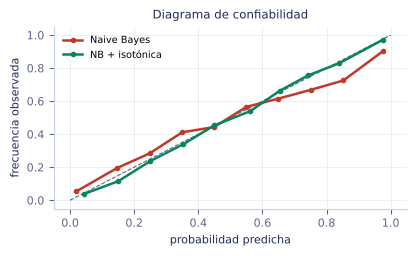

In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
X9, y9 = make_classification(n_samples=20000, n_features=20, n_informative=5, n_redundant=10, random_state=9)
a, b9, c9, d9 = train_test_split(X9, y9, test_size=0.5, random_state=0)
fig, ax = plt.subplots(figsize=U); ax.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=0.8)
for nom, mm, col in [("Naive Bayes", GaussianNB(), RED), ("NB + isotónica", CalibratedClassifierCV(GaussianNB(), method="isotonic"), GREEN)]:
    fp, mp = calibration_curve(d9, mm.fit(a, c9).predict_proba(b9)[:, 1], n_bins=10); ax.plot(mp, fp, "o-", color=col, ms=3, label=nom)
ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia observada"); ax.legend(); ax.set_title("Diagrama de confiabilidad"); plt.show()

### Ejemplo 2 — Temperature scaling multiclase (`t09b.py`)
- T = 2.14 > 1: el modelo era sobreconfiado.
- La exactitud no cambia; la NLL baja de 1.177 a 0.950.
- Confianza media (0.628) ≈ exactitud (0.632).

In [32]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import log_softmax

rng = np.random.default_rng(9)
n, K = 3000, 5                               # logits de una red sobreconfiada
y = rng.integers(0, K, n)
logits = rng.normal(0, 1, (n, K))
logits[np.arange(n), y] += 1.5               # señal real moderada
logits *= 3.0                                # sobreconfianza: logits inflados

def nll(T, Z, y):                            # entropía cruzada con temperatura T
    return -log_softmax(Z / T, axis=1)[np.arange(len(y)), y].mean()

val, test = slice(0, 1500), slice(1500, None)
T = minimize_scalar(lambda t: nll(t, logits[val], y[val]),
                    bounds=(0.05, 20), method="bounded").x
for nombre, t in [("Sin calibrar (T = 1)", 1.0), (f"Temperature scaling (T = {T:.2f})", T)]:
    P = np.exp(log_softmax(logits[test] / t, axis=1))
    acc = (P.argmax(1) == y[test]).mean()
    print(f"{nombre:31s} NLL = {nll(t, logits[test], y[test]):.3f}"
          f"  confianza = {P.max(1).mean():.3f}  exactitud = {acc:.3f}")

Sin calibrar (T = 1)            NLL = 1.177  confianza = 0.810  exactitud = 0.632
Temperature scaling (T = 2.14)  NLL = 0.950  confianza = 0.628  exactitud = 0.632


## 10 · Incertidumbre
*Regresión logística bayesiana y predicción conforme*

- **Prior:** β ~ N(0, α⁻¹I); expresa conocimiento previo y regulariza.
- **Posterior:** p(β | datos) ∝ Πᵢ Bernoulli(yᵢ | σ(βᵀxᵢ)) · prior; sin forma cerrada.
- **Aproximación de Laplace:** gaussiana centrada en β_MAP con covarianza S = (XᵀWX + αI)⁻¹.
- **MCMC / VI:** muestreo (NUTS en PyMC) o variacional para posteriores exactos o escalables.
- **Predictiva:** p(y = 1 | x) = ∫ σ(βᵀx) p(β | datos) dβ; modera las predicciones lejanas.
- **Aprox. probit (MacKay):** p ≈ σ(μ / √(1 + π s² / 8)) con μ = β_MAPᵀx y s² = xᵀSx.
- **Predicción conforme:** conjuntos C(x) con P(y ∈ C(x)) ≥ 1 − α sin suponer el modelo correcto.
- **Puntaje LAC:** s = 1 − p̂(y_verdadera | x); se calibra el cuantil q̂ en datos aparte.
- **Lectura:** conjuntos de una clase = confianza; conjuntos grandes = duda del modelo.

> `S = (Xᵀ W X + α I)⁻¹   (Laplace)`
> `C(x) = { k : 1 − p̂_k(x) ≤ q̂_(1−α) }`

### Ejemplo 1 — Laplace y predictiva moderada (`t10a.py`)
- El IC de β₁ es ancho con n = 40.
- p_bayes < p_MAP cuando sd(z) es grande.
- En x = 0 ambas coinciden.

In [33]:
import numpy as np
from scipy.optimize import minimize

rng = np.random.default_rng(10)
n = 40                                       # pocos datos ⇒ incertidumbre alta
X = np.column_stack([np.ones(n), rng.normal(0, 1, n)])
y = rng.binomial(1, 1 / (1 + np.exp(-(X @ np.array([-0.3, 1.8])))))
alpha = 1.0                                  # prior β ~ N(0, α⁻¹ I)

def neg_log_post(b):
    z = X @ b
    return np.sum(np.logaddexp(0, z) - y * z) + 0.5 * alpha * b @ b
m = minimize(neg_log_post, np.zeros(2)).x    # MAP
p = 1 / (1 + np.exp(-X @ m))
S = np.linalg.inv(X.T @ ((p * (1 - p))[:, None] * X) + alpha * np.eye(2))   # Laplace
ic = m[1] + np.array([-1.96, 1.96]) * np.sqrt(S[1, 1])
print("β_MAP =", np.round(m, 3), "  IC 95 % de β₁:", np.round(ic, 2))
sig = lambda t: 1 / (1 + np.exp(-t))
for x in [0.0, 2.0, 4.0]:                    # predictiva moderada (aprox. probit de MacKay)
    phi = np.array([1, x]); mu, var = phi @ m, phi @ S @ phi
    p_b = sig(mu / np.sqrt(1 + np.pi * var / 8))
    print(f"x = {x}: p_MAP = {sig(mu):.3f}  p_bayes = {p_b:.3f}  sd(z) = {np.sqrt(var):.2f}")

β_MAP = [0.008 1.487]   IC 95 % de β₁: [0.53 2.44]
x = 0.0: p_MAP = 0.502  p_bayes = 0.502  sd(z) = 0.34
x = 2.0: p_MAP = 0.952  p_bayes = 0.922  sd(z) = 1.07
x = 4.0: p_MAP = 0.997  p_bayes = 0.976  sd(z) = 2.02


**Gráfica del ejemplo resuelto**

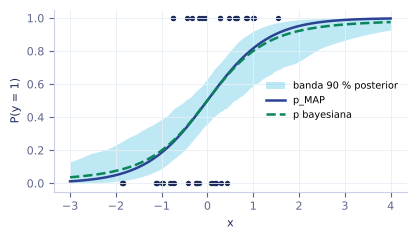

In [34]:
r10 = np.random.default_rng(10); X10 = np.column_stack([np.ones(40), r10.normal(0, 1, 40)]); y10 = r10.binomial(1, expit(X10 @ np.array([-0.3, 1.8])))
from scipy.optimize import minimize
mm = minimize(lambda b: np.sum(np.logaddexp(0, X10 @ b) - y10 * (X10 @ b)) + 0.5 * b @ b, np.zeros(2)).x
pq = expit(X10 @ mm); S = np.linalg.inv(X10.T @ ((pq * (1 - pq))[:, None] * X10) + np.eye(2))
xx = np.linspace(-3, 4, 200); Phi = np.column_stack([np.ones(200), xx]); mu = Phi @ mm; var = np.einsum("ij,jk,ik->i", Phi, S, Phi)
smp = r10.multivariate_normal(mm, S, 400); band = expit(Phi @ smp.T)
fig, ax = plt.subplots(figsize=U)
ax.fill_between(xx, np.quantile(band, 0.05, 1), np.quantile(band, 0.95, 1), color=CYAN, alpha=0.3, lw=0, label="banda 90 % posterior")
ax.plot(xx, expit(mu), color=NAVY, label="p_MAP"); ax.plot(xx, expit(mu / np.sqrt(1 + np.pi * var / 8)), color=GREEN, ls="--", label="p bayesiana")
ax.scatter(X10[:, 1], y10, s=8, color=DARK); ax.set_xlabel("x"); ax.set_ylabel("P(y = 1)"); ax.legend(loc="center right"); plt.show()

### Ejemplo 2 — Predicción conforme en dígitos (`t10b.py`)
- Cobertura ≈ 0.9 con cualquier modelo base.
- 89 % de los conjuntos tiene una sola clase.
- Los conjuntos grandes señalan dígitos dudosos.

In [35]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = load_digits(return_X_y=True)
X = X + np.random.default_rng(0).normal(0, 4, X.shape)    # ruido para que haya duda
Xtr, Xr, ytr, yr = train_test_split(X, y, test_size=0.6, random_state=0)
Xcal, Xte, ycal, yte = train_test_split(Xr, yr, test_size=0.5, random_state=0)
m = LogisticRegression(max_iter=5000).fit(Xtr / 16, ytr)

alpha = 0.10                                 # cobertura objetivo 90 %
s = 1 - m.predict_proba(Xcal / 16)[np.arange(len(ycal)), ycal]   # no conformidad
q = np.quantile(s, np.ceil((len(s) + 1) * (1 - alpha)) / len(s), method="higher")
conj = m.predict_proba(Xte / 16) >= 1 - q    # conjunto de predicción C(x)
print(f"q̂ = {q:.3f}   exactitud top-1 = {m.score(Xte / 16, yte):.3f}")
cob = conj[np.arange(len(yte)), yte].mean()
print(f"cobertura = {cob:.3f}  (objetivo ≈ {1 - alpha}; la garantía es en promedio)")
tam = conj.sum(1)
print(f"tamaño medio de C(x) = {tam.mean():.2f}  ·  con 1 sola clase: {(tam == 1).mean():.1%}")

q̂ = 0.728   exactitud top-1 = 0.859
cobertura = 0.893  (objetivo ≈ 0.9; la garantía es en promedio)
tamaño medio de C(x) = 1.11  ·  con 1 sola clase: 89.1%


## 11 · Interpretabilidad y equidad
*Odds ratios, SHAP lineal y métricas de fairness*

- **Odds ratio:** OR_j = e^βⱼ; OR = 2.5 ⇒ los odds se multiplican por 2.5 por unidad de xⱼ.
- **IC del OR:** exp(βⱼ ± 1.96·SE); si incluye 1, el efecto no es significativo.
- **Coeficientes estandarizados:** con X escalada, |βⱼ| compara la importancia en log-odds.
- **SHAP lineal:** φⱼ = βⱼ (xⱼ − E[xⱼ]); explica una predicción en el espacio logit.
- **Aditividad:** base + Σ φⱼ = logit(x); en probabilidad el efecto no es aditivo.
- **Asociación ≠ causa:** un OR alto no implica efecto causal si hay confusores.
- **Paridad demográfica:** P(ŷ = 1 | A) = P(ŷ = 1 | B); igual tasa de aprobación.
- **Igualdad de oportunidades:** TPR_A = TPR_B (Hardt et al., 2016); igual recall entre grupos.
- **Imposibilidad:** con prevalencias distintas no se cumplen a la vez calibración, DP y EO.

> `OR_j = e^βⱼ   ·   IC: e^(βⱼ ± 1.96 SEⱼ)`
> `ΔEO = TPR_A − TPR_B`

### Ejemplo 1 — Odds ratios y SHAP lineal (`t11a.py`)
- Fumar multiplica los odds por 2.5 [1.9, 3.3].
- Σφ + base reconstruye el logit exacto.
- La edad es la que más baja el riesgo de este caso.

In [36]:
import numpy as np, pandas as pd, statsmodels.api as sm

rng = np.random.default_rng(11)
n = 2000
df = pd.DataFrame({"edad": rng.uniform(20, 70, n), "fumador": rng.binomial(1, 0.3, n),
                   "imc": rng.normal(26, 4, n)})
z = -9 + 0.08 * df.edad + 0.9 * df.fumador + 0.12 * df.imc
df["evento"] = rng.binomial(1, 1 / (1 + np.exp(-z)))
res = sm.Logit(df.evento, sm.add_constant(df[["edad", "fumador", "imc"]])).fit(disp=0)

tabla = np.exp(pd.concat([res.params, res.conf_int()], axis=1)).iloc[1:]
tabla.columns = ["OR", "IC 2.5 %", "IC 97.5 %"]
print(tabla.round(3))
cols = ["edad", "fumador", "imc"]; b = res.params[cols]
x = df.iloc[0][cols]                         # paciente a explicar
base = res.params.const + b @ df[cols].mean()
phi = b * (x - df[cols].mean())             # φⱼ = βⱼ (xⱼ − E[xⱼ])
print("SHAP lineal (log-odds):", phi.round(3).to_dict())
print(f"base {base:.3f} + Σφ {phi.sum():.3f} = logit(x) {res.params.const + b @ x:.3f}")

            OR  IC 2.5 %  IC 97.5 %
edad     1.090     1.078      1.103
fumador  2.509     1.902      3.310
imc      1.138     1.100      1.178
SHAP lineal (log-odds): {'edad': -1.565, 'fumador': -0.264, 'imc': 0.266}
base -2.157 + Σφ -1.563 = logit(x) -3.720


**Gráfica del ejemplo resuelto**

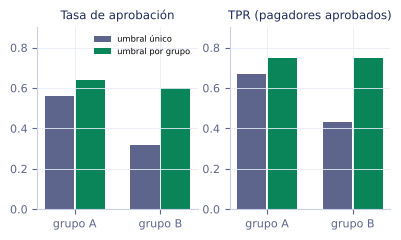

In [37]:
fig, axs = plt.subplots(1, 2, figsize=U)
lab = ["A", "B"]
for ax_, ttl, v1, v2 in [(axs[0], "Tasa de aprobación", [0.56, 0.32], [0.64, 0.60]), (axs[1], "TPR (pagadores aprobados)", [0.67, 0.43], [0.75, 0.75])]:
    xg = np.arange(2); ax_.bar(xg - 0.18, v1, 0.34, color=GRAY, label="umbral único"); ax_.bar(xg + 0.18, v2, 0.34, color=GREEN, label="umbral por grupo")
    ax_.set_xticks(xg, ["grupo A", "grupo B"]); ax_.set_title(ttl); ax_.set_ylim(0, 0.9)
axs[0].legend(loc="upper right", fontsize=6); plt.show()

### Ejemplo 2 — Auditoría de fairness (`t11b.py`)
- El umbral único aprueba menos al grupo B.
- Umbral por grupo iguala la TPR (EO).
- Corregir un criterio puede afectar otro.

In [38]:
import numpy as np
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(12)
n = 8000
g = rng.binomial(1, 0.5, n)                  # grupo protegido (0 = A, 1 = B)
ingreso = rng.normal(3 - 0.6 * g, 1, n)      # brecha histórica en el ingreso
paga = rng.binomial(1, 1 / (1 + np.exp(-(-2 + 1.0 * ingreso))))   # y real: paga el crédito
X = np.column_stack([ingreso, rng.normal(0, 1, n)])
p = LogisticRegression().fit(X, paga).predict_proba(X)[:, 1]

def reporte(nombre, aprob):
    tasa = [aprob[g == k].mean() for k in (0, 1)]                    # paridad demográfica
    tpr = [aprob[(g == k) & (paga == 1)].mean() for k in (0, 1)]     # igualdad de oportunidades
    print(f"{nombre:22s} aprob A/B = {tasa[0]:.2f}/{tasa[1]:.2f}  ΔDP = {tasa[0]-tasa[1]:.2f}"
          f"  TPR A/B = {tpr[0]:.2f}/{tpr[1]:.2f}  ΔEO = {tpr[0]-tpr[1]:.2f}")
reporte("Umbral único 0.7", p >= 0.7)
t = {k: np.quantile(p[(g == k) & (paga == 1)], 0.25) for k in (0, 1)}   # TPR = 0.75 en ambos
reporte("Umbral por grupo (EO)", np.where(g == 0, p >= t[0], p >= t[1]))

Umbral único 0.7       aprob A/B = 0.56/0.32  ΔDP = 0.25  TPR A/B = 0.67/0.43  ΔEO = 0.23
Umbral por grupo (EO)  aprob A/B = 0.64/0.60  ΔDP = 0.04  TPR A/B = 0.75/0.75  ΔEO = 0.00


## 12 · Embeddings + regresión logística
*Clasificación de texto: de TF-IDF a embeddings de modelos de lenguaje*

- **Tarea:** y es una clase (sentimiento, intención, spam) y x es un texto.
- **TF-IDF:** vector disperso de pesos por palabra; línea base fuerte e interpretable.
- **Embedding:** un encoder (BERT, E5, modelos de sentence-transformers) convierte el texto en h ∈ ℝᵈ.
- **Linear probe / cabeza:** LR sobre h congelado; entrena en segundos y sin GPU.
- **Por qué funciona:** los embeddings ya separan linealmente muchas propiedades semánticas.
- **Regularización:** con d = 384–4096 y pocos ejemplos se necesita L2 y CV.
- **Interpretabilidad:** con TF-IDF cada βⱼ es una palabra; con embeddings se pierde.
- **Alternativas:** fine-tuning completo, LoRA o few-shot con un LLM generativo.
- **Costo:** LR sobre embeddings es órdenes de magnitud más barata que llamar un LLM por texto.

> `h = Encoder(texto) ∈ ℝᵈ`
> `P(y = 1 | texto) = σ(wᵀh + b)`

### Ejemplo 1 — TF-IDF + regresión logística (`t12a.py`)
- Los coeficientes señalan palabras clave.
- El ruido de etiquetas limita la exactitud.
- Pipeline evita fuga del vocabulario.

In [39]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(12)
pos = ["excelente", "rápido", "amable", "recomiendo", "perfecto", "encantó"]
neg = ["pésimo", "lento", "grosero", "nunca", "roto", "decepcionó"]
neutras = ["el", "servicio", "producto", "pedido", "fue", "muy", "la", "entrega"]
def resena(y):                               # reseña sintética con algo de ruido
    clave = rng.choice(pos if y else neg, 2).tolist() + rng.choice(pos + neg, 2).tolist()
    return " ".join(rng.permutation(clave + rng.choice(neutras, 5).tolist()))
y = rng.integers(0, 2, 600)
textos = [resena(v) for v in y]
y = np.where(rng.random(600) < 0.08, 1 - y, y)   # 8 % de etiquetas ruidosas

clf = make_pipeline(TfidfVectorizer(), LogisticRegression())
print("ejemplo:", textos[0], "→", y[0])
print(f"exactitud CV (TF-IDF + LR) = {cross_val_score(clf, textos, y, cv=5).mean():.3f}")
vocab, coef = clf.fit(textos, y)[0].get_feature_names_out(), clf[-1].coef_[0]
print("más positivas:", vocab[np.argsort(coef)[-3:]][::-1])
print("más negativas:", vocab[np.argsort(coef)[:3]])

ejemplo: entrega fue recomiendo roto fue encantó pedido la recomiendo → 1


exactitud CV (TF-IDF + LR) = 0.790
más positivas: ['amable' 'recomiendo' 'perfecto']
más negativas: ['grosero' 'decepcionó' 'lento']


**Gráfica del ejemplo resuelto**

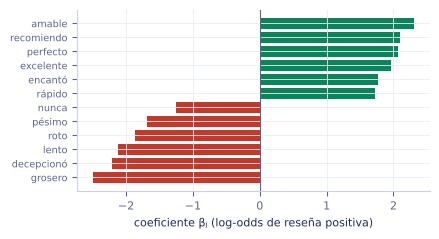

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
clf = make_pipeline(TfidfVectorizer(), LogisticRegression()).fit(textos, y)
voc, cf = clf[0].get_feature_names_out(), clf[-1].coef_[0]; idx = np.r_[np.argsort(cf)[:6], np.argsort(cf)[-6:]]
fig, ax = plt.subplots(figsize=U)
ax.barh(voc[idx], cf[idx], color=[RED if v < 0 else GREEN for v in cf[idx]]); ax.axvline(0, color=GRAY, lw=0.8)
ax.set_xlabel("coeficiente βⱼ (log-odds de reseña positiva)"); ax.tick_params(axis="y", labelsize=7); plt.show()

### Ejemplo 2 — Embedding denso + regresión logística (`t12b.py`)
- Cada reseña pasa a un vector de k dims.
- 5 dimensiones bastan para este corpus.
- Cambiar LSA por SentenceTransformer es 1 línea.

In [41]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Reutiliza `textos` e `y` del ejemplo anterior (t12a)

# Embedding denso: aquí LSA (TF-IDF → SVD). Con internet se reemplaza por, p. ej.:
#   from sentence_transformers import SentenceTransformer
#   E = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2").encode(textos)
for k in [2, 5, 10]:
    emb = make_pipeline(TfidfVectorizer(), TruncatedSVD(n_components=k, random_state=0))
    E = emb.fit_transform(textos)            # cada reseña → vector de k dimensiones
    acc = cross_val_score(LogisticRegression(max_iter=1000), E, y, cv=5).mean()
    print(f"embedding de {k:2d} dims → exactitud CV = {acc:.3f}")

embedding de  2 dims → exactitud CV = 0.772
embedding de  5 dims → exactitud CV = 0.807
embedding de 10 dims → exactitud CV = 0.777


## 13 · Probing lineal
*Clasificadores logísticos para leer el interior de una red*

- **Probe lineal:** LR entrenada sobre las activaciones h_ℓ de la capa ℓ para predecir una propiedad.
- **Pregunta:** ¿la capa ℓ codifica linealmente la propiedad (sintaxis, verdad, sentimiento)?
- **Linear classifier probes:** Alain & Bengio (2016) los propusieron para redes profundas.
- **Hipótesis de representación lineal:** muchos conceptos son direcciones en el espacio de activaciones.
- **Probes de verdad:** separan afirmaciones verdaderas y falsas en LLM (Marks & Tegmark, 2024).
- **Tarea de control:** etiquetas aleatorias miden cuánto memoriza el probe (Hewitt & Liang, 2019).
- **Selectividad:** exactitud(tarea) − exactitud(control); alta = la información está en h.
- **Diferencia de medias:** w = μ₁ − μ₀; probe simple y robusto, usado para steering.
- **Precaución:** que un probe lea una propiedad no prueba que el modelo la use.

> `P(propiedad | h_ℓ) = σ(wᵀh_ℓ + b)`
> `Selectividad = acc(tarea) − acc(control)`

### Ejemplo 1 — Probes por capa en una MLP (`t13a.py`)
- La activación h se calcula con coefs_.
- Control ≈ 0.5: el probe no memoriza.
- La selectividad crece con la profundidad.

In [42]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X, digito = load_digits(return_X_y=True); X = X / 16
red = MLPClassifier((64, 32), max_iter=600, random_state=0).fit(X, digito)  # tarea: dígito 0–9

def capas(X):                                # activaciones h₁ y h₂ (ReLU)
    h1 = np.maximum(0, X @ red.coefs_[0] + red.intercepts_[0])
    return {"entrada": X, "capa 1": h1,
            "capa 2": np.maximum(0, h1 @ red.coefs_[1] + red.intercepts_[1])}
par = (digito % 2 == 0).astype(int)          # propiedad NO entrenada: ¿es par?
control = np.random.default_rng(0).permutation(par)          # tarea de control
for nombre, H in capas(X).items():
    probe = LogisticRegression(max_iter=3000)
    a, c = (cross_val_score(probe, H, t, cv=5).mean() for t in (par, control))
    print(f"{nombre:8s} probe 'par' = {a:.3f}   control = {c:.3f}   selectividad = {a - c:.3f}")

entrada  probe 'par' = 0.896   control = 0.495   selectividad = 0.402


capa 1   probe 'par' = 0.935   control = 0.504   selectividad = 0.431


capa 2   probe 'par' = 0.960   control = 0.512   selectividad = 0.449


**Gráfica del ejemplo resuelto**

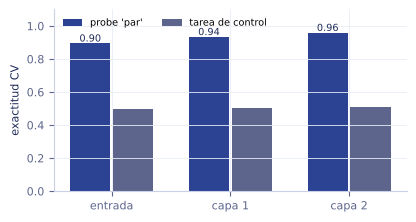

In [43]:
fig, ax = plt.subplots(figsize=U)
cap = ["entrada", "capa 1", "capa 2"]; a1 = [0.896, 0.935, 0.960]; c1 = [0.495, 0.504, 0.512]; xg = np.arange(3)
ax.bar(xg - 0.18, a1, 0.34, color=NAVY, label="probe 'par'"); ax.bar(xg + 0.18, c1, 0.34, color=GRAY, label="tarea de control")
for i in range(3): ax.text(i - 0.18, a1[i] + 0.01, f"{a1[i]:.2f}", ha="center", fontsize=7, color=DARK)
ax.set_xticks(xg, cap); ax.set_ylim(0, 1.1); ax.set_ylabel("exactitud CV"); ax.legend(loc="upper left", ncol=2); plt.show()

### Ejemplo 2 — Dirección de 'verdad' simulada (`t13b.py`)
- La exactitud crece con la señal por capa.
- cos(w, v) → 0.91: el probe halla la dirección.
- Diferencia de medias ≈ LR.

In [44]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(13)
d, n = 256, 2000                             # activaciones simuladas de un LLM
v = rng.normal(0, 1, d); v /= np.linalg.norm(v)              # dirección "verdad"
y = rng.integers(0, 2, n)                    # 1 = afirmación verdadera
for capa, s in [(4, 0.2), (12, 1.0), (20, 2.5)]:             # la señal crece con la capa
    H = rng.normal(0, 1, (n, d)) + s * np.outer(2 * y - 1, v)
    Htr, Hte, ytr, yte = train_test_split(H, y, random_state=0)
    lr = LogisticRegression(max_iter=2000).fit(Htr, ytr)
    w = lr.coef_[0] / np.linalg.norm(lr.coef_[0])
    dm = Htr[ytr == 1].mean(0) - Htr[ytr == 0].mean(0)       # probe de diferencia de medias
    acc_dm = np.mean(((Hte - Htr.mean(0)) @ dm > 0) == yte)
    acc_lr = lr.score(Hte, yte)
    print(f"capa {capa:2d}: LR = {acc_lr:.3f}  dif. medias = {acc_dm:.3f}  cos(w, v) = {w @ v:.2f}")

capa  4: LR = 0.522  dif. medias = 0.548  cos(w, v) = 0.44
capa 12: LR = 0.794  dif. medias = 0.796  cos(w, v) = 0.82
capa 20: LR = 0.990  dif. medias = 0.990  cos(w, v) = 0.91


## 14 · La softmax de salida de un LLM
*Logits, temperatura y entropía cruzada del siguiente token*

- **Cabeza de lenguaje:** logits z = W h + b con W ∈ ℝ^(V×d); V = tamaño del vocabulario.
- **Softmax:** P(token k | contexto) = e^z_k / Σⱼ e^zⱼ: una regresión logística multinomial.
- **Pérdida de preentrenamiento:** entropía cruzada −ln P(token real); la misma del tópico 06.
- **Perplejidad:** PPL = e^CE; número efectivo de opciones entre las que duda el modelo.
- **Temperatura:** softmax(z / T): T < 1 concentra, T > 1 aplana; T → 0 = greedy.
- **Logprobs:** las APIs exponen ln P(token); base de clasificación y calibración (tópico 16).
- **Top-k / top-p:** muestreo restringido a los tokens más probables.
- **Diferencia clave:** h no es fijo: el transformer aprende la representación y la cabeza a la vez.
- **Cabeza lineal congelada:** con h fijo, ajustar W es exactamente una LR multinomial.

> `P(wₜ = k | w<ₜ) = softmax(W hₜ / T)_k`
> `PPL = exp( −(1/N) Σ ln P(wₜ | w<ₜ) )`

### Ejemplo 1 — Softmax con temperatura (`t14a.py`)
- T bajo ≈ greedy; T alto ≈ uniforme.
- La pérdida es −ln P(token real).
- Muestrear con T = 1 varía la salida.

In [45]:
import numpy as np

vocab = ["gato", "perro", "carro", "sol", "mesa", "luna"]
logits = np.array([3.2, 2.9, 0.5, 1.4, -0.3, 1.1])  # salida W·h + b del último bloque

def softmax(z, T=1.0):
    e = np.exp((z - z.max()) / T)
    return e / e.sum()
for T in [0.5, 1.0, 2.0]:
    p = softmax(logits, T)
    H = -(p * np.log2(p)).sum()
    dist = "  ".join(f"{w}={pi:.2f}" for w, pi in zip(vocab, p))
    print(f"T = {T}: {dist}   H = {H:.2f} bits")
p = softmax(logits)
print(f"token real 'perro' → pérdida = −log p = {-np.log(p[1]):.3f} nats")
muestras = np.random.default_rng(0).choice(vocab, 5, p=p)
print("greedy:", vocab[p.argmax()], "· muestreo T=1:", muestras)

T = 0.5: gato=0.63  perro=0.34  carro=0.00  sol=0.02  mesa=0.00  luna=0.01   H = 1.15 bits
T = 1.0: gato=0.47  perro=0.35  carro=0.03  sol=0.08  mesa=0.01  luna=0.06   H = 1.81 bits
T = 2.0: gato=0.33  perro=0.28  carro=0.08  sol=0.13  mesa=0.06  luna=0.11   H = 2.33 bits
token real 'perro' → pérdida = −log p = 1.054 nats
greedy: gato · muestreo T=1: ['perro' 'gato' 'gato' 'gato' 'perro']


**Gráfica del ejemplo resuelto**

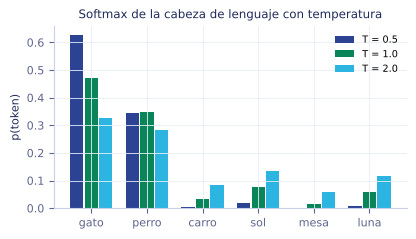

In [46]:
vocab = ["gato", "perro", "carro", "sol", "mesa", "luna"]; lg = np.array([3.2, 2.9, 0.5, 1.4, -0.3, 1.1]); xg = np.arange(6)
fig, ax = plt.subplots(figsize=U)
for k, (T, col) in enumerate([(0.5, NAVY), (1.0, GREEN), (2.0, CYAN)]):
    pz = np.exp(lg / T) / np.exp(lg / T).sum(); ax.bar(xg + (k - 1) * 0.26, pz, 0.24, color=col, label=f"T = {T}")
ax.set_xticks(xg, vocab); ax.set_ylabel("p(token)"); ax.legend(); ax.set_title("Softmax de la cabeza de lenguaje con temperatura"); plt.show()

### Ejemplo 2 — La cabeza de lenguaje como LR multinomial (`t14b.py`)
- PPL 1.79 frente a 8 de un modelo uniforme.
- LogisticRegression recupera W (corr 0.996).
- Es la última capa de cualquier LLM.

In [47]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(14)
V, d, n = 8, 16, 6000                        # vocabulario, dim. oculta, contextos
W = rng.normal(0, 1.2, (V, d))               # "cabeza de lenguaje" verdadera
h = rng.normal(0, 1, (n, d))                 # estados ocultos congelados del transformer
z = h @ W.T
tok = np.array([rng.choice(V, p=np.exp(r - r.max()) / np.exp(r - r.max()).sum()) for r in z])

htr, hte, ttr, tte = train_test_split(h, tok, random_state=0)
cabeza = LogisticRegression(C=10, max_iter=3000).fit(htr, ttr)   # softmax + entropía cruzada
ce = log_loss(tte, cabeza.predict_proba(hte))
print(f"entropía cruzada = {ce:.3f} nats   perplejidad = {np.exp(ce):.2f}  (uniforme = {V})")
print(f"exactitud del siguiente token = {cabeza.score(hte, tte):.3f}")
# W solo es identificable salvo una constante por columna: se compara centrada
r = np.corrcoef(cabeza.coef_.ravel(), (W - W.mean(0)).ravel())[0, 1]
print(f"corr(W estimada, W real) = {r:.3f}")

entropía cruzada = 0.580 nats   perplejidad = 1.79  (uniforme = 8)
exactitud del siguiente token = 0.785


corr(W estimada, W real) = 0.996


## 15 · Bradley–Terry, RLHF y DPO
*La pérdida logística sobre preferencias humanas*

- **Comparaciones por pares:** un humano prefiere la respuesta y_w sobre y_l para el mismo prompt.
- **Bradley–Terry (1952):** P(i ≻ j) = σ(sᵢ − sⱼ); una LR sobre diferencias de puntajes.
- **Elo / Chatbot Arena:** clasificaciones de LLM con BT; Elo = 1000 + (400 / ln 10)·s.
- **Modelo de recompensa (RLHF):** r_θ(x, y) entrenado con −ln σ(r(x, y_w) − r(x, y_l)).
- **RLHF:** luego se optimiza la política con PPO para maximizar r con penalización KL.
- **DPO (Rafailov et al., 2023):** elimina el modelo de recompensa: r implícita = β ln(π / π_ref).
- **Pérdida DPO:** −ln σ(β[ln π(y_w)/π_ref(y_w) − ln π(y_l)/π_ref(y_l)]): la misma forma logística.
- **Peso del gradiente:** σ(−margen): aprende más de los pares que todavía clasifica mal.
- **β:** controla cuánto se aleja la política de la referencia.

> `Bradley–Terry:  P(y_w ≻ y_l) = σ(r_w − r_l)`
> `L_DPO = −ln σ(β [Δ log π − Δ log π_ref])`

### Ejemplo 1 — Bradley–Terry con LogisticRegression (`t15a.py`)
- Cada fila: +1 al modelo i, −1 al j.
- Los coeficientes son las habilidades s.
- Elo es solo un cambio de escala.

In [48]:
import numpy as np
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(15)
modelos = ["A", "B", "C", "D", "E"]
fuerza = np.array([1.2, 0.6, 0.0, -0.4, -1.4])           # habilidad latente real
pares = rng.integers(0, 5, (3000, 2)); pares = pares[pares[:, 0] != pares[:, 1]]
gana_i = rng.binomial(1, 1 / (1 + np.exp(-(fuerza[pares[:, 0]] - fuerza[pares[:, 1]]))))

X = np.zeros((len(pares), 5))                # +1 al modelo i, −1 al modelo j
X[np.arange(len(pares)), pares[:, 0]] = 1
X[np.arange(len(pares)), pares[:, 1]] = -1
bt = LogisticRegression(fit_intercept=False, C=np.inf).fit(X, gana_i)
s = bt.coef_[0] - bt.coef_[0].mean()         # Bradley–Terry: P(i ≻ j) = σ(sᵢ − sⱼ)
elo = 1000 + 400 / np.log(10) * s            # misma escala que Elo / Chatbot Arena
for k in np.argsort(-s):
    real = fuerza[k] - fuerza.mean()
    print(f"modelo {modelos[k]}: s = {s[k]:+.2f} (real {real:+.2f})  Elo ≈ {elo[k]:.0f}")
print(f"P(A ≻ E) = {1 / (1 + np.exp(-(s[0] - s[4]))):.3f}")

modelo A: s = +1.23 (real +1.20)  Elo ≈ 1214
modelo B: s = +0.56 (real +0.60)  Elo ≈ 1097
modelo C: s = -0.02 (real +0.00)  Elo ≈ 996
modelo D: s = -0.37 (real -0.40)  Elo ≈ 935
modelo E: s = -1.39 (real -1.40)  Elo ≈ 758
P(A ≻ E) = 0.932


**Gráfica del ejemplo resuelto**

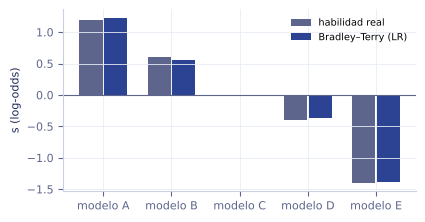

In [49]:
fig, ax = plt.subplots(figsize=U)
mods = ["A", "B", "C", "D", "E"]; est = [1.23, 0.56, -0.02, -0.37, -1.39]; real = [1.20, 0.60, 0.0, -0.40, -1.40]; xg = np.arange(5)
ax.bar(xg - 0.18, real, 0.34, color=GRAY, label="habilidad real"); ax.bar(xg + 0.18, est, 0.34, color=NAVY, label="Bradley–Terry (LR)")
ax.axhline(0, color=GRAY, lw=0.8); ax.set_xticks(xg, [f"modelo {m_}" for m_ in mods]); ax.set_ylabel("s (log-odds)"); ax.legend(); plt.show()

### Ejemplo 2 — Pérdida DPO paso a paso (`t15b.py`)
- Recompensa implícita r = β log(π/π_ref).
- Margen negativo ⇒ pérdida y peso mayores.
- Es una LR sobre márgenes de recompensa.

In [50]:
import numpy as np

beta = 0.1                                   # fuerza del ancla a la política de referencia
# log π(y|x) de la política y de la referencia para (respuesta preferida, rechazada)
pol_w, pol_l = np.array([-12.0, -20.0, -15.0]), np.array([-14.0, -18.0, -15.5])
ref_w, ref_l = np.array([-13.0, -19.0, -15.0]), np.array([-13.0, -19.0, -15.0])

r_w = beta * (pol_w - ref_w)                 # recompensa implícita r = β log(π/π_ref)
r_l = beta * (pol_l - ref_l)
margen = r_w - r_l
perdida = np.logaddexp(0, -margen)           # −log σ(margen): pérdida logística
peso = 1 / (1 + np.exp(margen))              # σ(−margen): peso del gradiente
for i in range(3):
    print(f"par {i}: margen = {margen[i]:+.2f}  pérdida = {perdida[i]:.3f}  peso = {peso[i]:.3f}")
print(f"pérdida DPO media = {perdida.mean():.3f}  (BT sobre recompensas implícitas)")

par 0: margen = +0.20  pérdida = 0.598  peso = 0.450
par 1: margen = -0.20  pérdida = 0.798  peso = 0.550
par 2: margen = +0.05  pérdida = 0.668  peso = 0.488
pérdida DPO media = 0.688  (BT sobre recompensas implícitas)


## 16 · LLM como clasificadores y jueces
*Logprobs, P(sí) calibrada y regresión logística sobre sus puntajes*

- **Zero-shot con logprobs:** preguntar '¿Es correcta? Sí/No' y leer ln P('Sí') y ln P('No').
- **Puntaje del juez:** z = ln P('Sí') − ln P('No'); P(Sí) = σ(z) normalizando entre las dos opciones.
- **LLM-as-a-judge:** un LLM evalúa respuestas de otros modelos (Zheng et al., 2023).
- **Sobreconfianza:** los jueces dan P cercanas a 0 o 1 aunque se equivoquen.
- **Platt sobre el juez:** σ(a·z + b) ajustado con pocas etiquetas humanas calibra el juez.
- **Apilamiento (stacking):** LR que combina varios jueces, prompts y señales (longitud, fuentes).
- **Sesgos del juez:** longitud, posición, autopreferencia; la LR los hace visibles en sus pesos.
- **Validación humana:** un conjunto etiquetado por personas es indispensable para calibrar y auditar.
- **Costo:** la LR es el último paso barato sobre puntajes caros de obtener.

> `z = ln P(Sí) − ln P(No)   ·   P(Sí) = σ(z)`
> `P(correcta) = σ(w₁z₁ + … + w_m z_m + b)`

### Ejemplo 1 — Calibrar un LLM-juez con Platt (`t16a.py`)
- a < 1: el juez exageraba la confianza.
- El ECE baja de 0.153 a 0.010.
- Bastan unas 2000 etiquetas humanas.

In [51]:
import numpy as np
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(16)
n = 4000                                     # salidas simuladas de un LLM-juez
y = rng.binomial(1, 0.4, n)                  # 1 = la respuesta es correcta
lp_si = rng.normal(-0.4 + 1.6 * y, 1.0, n)   # logprob del token "Sí"
lp_no = rng.normal(0.4 - 1.6 * y, 1.0, n)    # logprob del token "No"
z = 3.0 * (lp_si - lp_no)                    # el juez es sobreconfiado
p_llm = 1 / (1 + np.exp(-z))                 # P(Sí) = softmax sobre {Sí, No}

def ece(y, p, b=10):
    k = np.minimum((p * b).astype(int), b - 1)
    return sum(abs(y[k == i].mean() - p[k == i].mean()) * np.mean(k == i)
               for i in range(b) if np.any(k == i))
cal, test = slice(0, 2000), slice(2000, None)
platt = LogisticRegression().fit(z[cal, None], y[cal])     # Platt: σ(a·z + b)
p_cal = platt.predict_proba(z[test, None])[:, 1]
print(f"a = {platt.coef_[0, 0]:.3f}  b = {platt.intercept_[0]:.3f}")
e0, e1 = ece(y[test], p_llm[test]), ece(y[test], p_cal)
print(f"ECE juez crudo = {e0:.3f}   ECE con Platt = {e1:.3f}")

a = 0.552  b = -1.647
ECE juez crudo = 0.153   ECE con Platt = 0.010


**Gráfica del ejemplo resuelto**

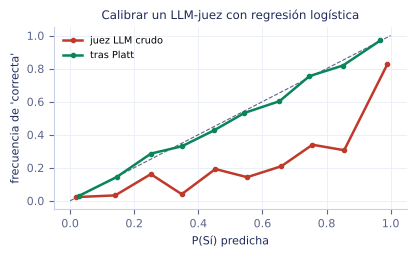

In [52]:
from sklearn.calibration import calibration_curve
plat = LogisticRegression().fit(z[:2000, None], y[:2000]); pc = plat.predict_proba(z[2000:, None])[:, 1]
fig, ax = plt.subplots(figsize=U); ax.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=0.8)
for nom, pv, col in [("juez LLM crudo", p_llm[2000:], RED), ("tras Platt", pc, GREEN)]:
    fp, mp = calibration_curve(y[2000:], pv, n_bins=10); ax.plot(mp, fp, "o-", color=col, ms=3, label=nom)
ax.set_xlabel("P(Sí) predicha"); ax.set_ylabel("frecuencia de 'correcta'"); ax.legend(); ax.set_title("Calibrar un LLM-juez con regresión logística"); plt.show()

### Ejemplo 2 — Apilar varios jueces con LR (`t16b.py`)
- El apilado supera a cada juez por separado.
- El peso de la longitud revela un sesgo.
- En la práctica z sale de logprobs de la API.

In [53]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(17)
n = 3000
y = rng.binomial(1, 0.5, n)                  # 1 = respuesta aceptable
S = np.column_stack([                        # puntajes logit de 3 jueces + longitud
    rng.normal(1.2 * y, 1.0, n),             # juez 1: prompt directo
    rng.normal(0.8 * y, 1.0, n),             # juez 2: rúbrica con CoT
    rng.normal(0.5 * y, 1.0, n),             # juez 3: modelo pequeño
    rng.normal(300 + 40 * y, 80, n) / 100])  # sesgo de longitud (respuesta larga)
# En la práctica: logprobs=True en la API → logit = lp("Sí") − lp("No") por juez
nombres = ["juez 1", "juez 2", "juez 3", "longitud"]
for j, nom in enumerate(nombres):
    print(f"{nom:9s} AUC = {roc_auc_score(y, S[:, j]):.3f}")
p = cross_val_predict(LogisticRegression(), S, y, cv=5, method="predict_proba")[:, 1]
pesos = LogisticRegression().fit(S, y).coef_[0]
print(f"apilado (LR) AUC = {roc_auc_score(y, p):.3f}  pesos = {np.round(pesos, 2)}")

juez 1    AUC = 0.796
juez 2    AUC = 0.728
juez 3    AUC = 0.621
longitud  AUC = 0.637
apilado (LR) AUC = 0.872  pesos = [1.2  0.89 0.46 0.61]


## Ejercicios
1. Cambia la semilla de varios ejemplos: ¿qué resultados son estables y cuáles no?
2. En el tópico 04, cambia la razón de costos C_FN/C_FP y predice el nuevo umbral antes de ejecutarlo.
3. En el tópico 12, reemplaza LSA por un modelo de `sentence-transformers` y compara la exactitud.
4. En el tópico 16, quita la variable de longitud del apilado: ¿cuánto cae la AUC y por qué es deseable?